In [ ]:
import random
import time
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import gc

In [2]:
class RSA:
    """
    RSA implementation for encryption, signature and station-to-station key exchange.
    """

    def __init__(self, private_key: int = None, public_key: int = None, n: int = None, fast_exp: callable = None) -> None:
        self.private_key = private_key
        self.public_key = public_key
        self.n = n
        self.challenge = "Bravo ! Je suis épousplouffé par ta maîtrise du timing attack sur RSA !"
        self.fast_exp = fast_exp if fast_exp is not None else self._default_fast_exp
    
    def copy(self):
        return RSA(self.private_key, self.public_key, self.n, self.fast_exp)

    def _default_fast_exp(self, y: int, x: int, n: int) -> int:
        """Apply fast exponentiation for y^x modulo n"""
        s = 1
        y %= n

        while x > 0:
            if (x % 2) == 1:
                s = (s * y) % n
            y = (y * y) % n
            x = x >> 1

        return s

    def setKeys(self, private_key: int, public_key: int, n: int) -> None:
        self.private_key = private_key
        self.public_key = public_key
        self.n = n

    def getKeys(self) -> list:
        return [self.public_key, self.n], [self.private_key, self.n]
    
    def exportPublicKey(self) -> list:
        return [self.public_key, self.n]

    def createKeyPair(self, size: int) -> list:
        p = self.primary_nb_generator(2**(size//2 - 1), 2**(size//2))
        q = self.primary_nb_generator(2**(size//2 - 1), 2**(size//2))
        n, e, d = self.key_generator(p, q, size=size)
        self.setKeys(d, e, n)
        return [n, e, d]

    def encrypt(self, message: int) -> int:
        return self.fast_exp(message, self.public_key, self.n)

    def decrypt(self, cipher: int, private_key: int = None) -> int:
        if private_key is not None:
            return self.fast_exp(cipher, private_key, self.n)
        return self.fast_exp(cipher, self.private_key, self.n)
    
    def createChallenge(self) -> int:
        challenge_int = int.from_bytes(self.challenge.encode(), 'big')
        self.challenge = self.encrypt(challenge_int)
        return self.challenge
    
    def decryptChallenge(self, tested_key: int) -> str:
        decrypted_challenge_int = self.decrypt(self.challenge, private_key=tested_key)
        decrypted_challenge_bytes = decrypted_challenge_int.to_bytes((decrypted_challenge_int.bit_length() + 7) // 8, 'big')
        return decrypted_challenge_bytes.decode()

    def fermat_test(self, n: int) -> bool:
        """
        Check if a number is primary by running Fermat test.
        """
        for _ in range(20):
            alpha = random.randint(2, n - 1)
            if self.fast_exp(alpha, n - 1, n) != 1:
                return False
        return True

    def primary_nb_generator(self, a: int, b: int, safe_prime: bool = False) -> int:
        """
        Generate primary number in range a, b

        Parameters
        ----------
        a : int
            lower bound
        b : int
            upper bound
        safe_prime : bool
            Generate primary number p with (p - 1) / 2 also primary

        Returns
        -------
        int
            Primary number generated

        """
        while True:
            p = random.randint(a, b)
            if self.fermat_test(p):
                if safe_prime:
                    if self.fermat_test((p - 1) / 2):
                        return p
                else:
                    return p

    def Euclide(self, a: int, b: int) -> list:
        """
        Euclide's extended algorithm, used to find decryption exponent d for RSA
        Return a list [pgcd(a, b), inverse of a mod b, inverse of b mod a]

        """
        if b > a:
            a, b = b, a  # swap

        r_0, r_1 = a, b
        s_0, s_1 = 1, 0
        t_0, t_1 = 0, 1

        while r_1 != 0:
            q = r_0 // r_1
            r_0, r_1 = r_1, r_0 - q * r_1
            s_0, s_1 = s_1, s_0 - q * s_1
            t_0, t_1 = t_1, t_0 - q * t_1

        return [r_0, s_0 % b, t_0 % a]

    def key_generator(self, p: int = 0, q: int = 0, e: int = 0, size: int = 512) -> list:
        """
        Generate public and private key for RSA
        """
        if p == 0:
            p = self.primary_nb_generator(2**(size//2 - 1), 2**(size//2))
        if q == 0:
            q = self.primary_nb_generator(2**(size//2 - 1), 2**(size//2))

        assert self.fermat_test(p), "p is not primary"
        assert self.fermat_test(q), "q is not primary"
        n = p * q
        phi_n = (p - 1) * (q - 1)

        if e != 0:
            pgcd, _, d = self.Euclide(phi_n, e)
            assert pgcd == 1, "pgcd(phi_n, e) is not equal to 1, so no private key found !"

        else:
            # Find a primary number e with phi_n
            while True:
                e = random.randint(2**(size - 1), 2**(size))
                pgcd, _, d = self.Euclide(phi_n, e)

                # If primary number with phi_n, claim public key
                if pgcd == 1:
                    break
        return n, e, d

In [3]:
#----------------------------------------------------------------------------
# Examples values
#----------------------------------------------------------------------------

# for RSA encryption :

p_A = 13109499994810966779468866046493465498469807493634236479294124421385342920350717814807375283698575766763256101470694189234369358996750113963585617491399169
q_A = 9497561827984502554523100157901534504433126034087863778629488755692649311435921364240405549590851856701860175924335776598684751639633322074428628372725777
n_A = p_A * q_A
e_A = 4574830074548708213
m_1 = 123456789132456789

# Expected results :
# 1) Check if p and q are indeed prime, then compute d_A and the ciphertext.
# 2) Expected values for d_A and the ciphertext (d_A is also used for station-to-station later)
d_A = 1685394382767324790326942621450485552187209875614438478305225564629345944620726038114923060947436330701451901921041511234432041036987266468290187679773130363479895993621867708066144608084390089775045890165825736468637468786667820591136139480545376198614216373031208691260339805721685482401743494212035728605
# cipher = 32468932964181322647810913060097066975304467072050643211304428656476623133068329653886195740426516038144100129255895281039142864272296799126753030014464755203797098445143314298922512718785433009136404533290100525054356166805463645892708927694801117827432767298393815743170470207262077229267156532545837844746
# 3) And show the decryption indeed finds the correct message m_1.

print("\n=============== RSA ENCRYPTION ===============\n")

RSA_instance = RSA()
n, e, d = RSA_instance.key_generator(p_A, q_A, e_A)
RSA_instance.setKeys(d, e, n)
assert d == d_A, "Private key generated is different from the expected key !"

print(f"Message:                {m_1}\n")

cipher = RSA_instance.encrypt(m_1)
assert cipher == 32468932964181322647810913060097066975304467072050643211304428656476623133068329653886195740426516038144100129255895281039142864272296799126753030014464755203797098445143314298922512718785433009136404533290100525054356166805463645892708927694801117827432767298393815743170470207262077229267156532545837844746, "Encrypted message is not correct !"
print(f"Ciphertext:             {cipher}\n")

recovered_message = RSA_instance.decrypt(cipher)
assert recovered_message == m_1, "Recovered message is different from original message !"
print(f"Decrypted ciphertext:   {recovered_message}")


=============== RSA ENCRYPTION ===============

Message:                123456789132456789

Ciphertext:             32468932964181322647810913060097066975304467072050643211304428656476623133068329653886195740426516038144100129255895281039142864272296799126753030014464755203797098445143314298922512718785433009136404533290100525054356166805463645892708927694801117827432767298393815743170470207262077229267156532545837844746

Decrypted ciphertext:   123456789132456789


In [28]:
def collect_samples(RSA_instance: RSA, num_samples: int = 1000, num_repetitions: int = 1, server: bool = True, private_key: int = None, progress_bar: bool = True) -> list:
    """
    Collect samples of decryption times for different cipher texts.

    Parameters
    ----------
    RSA_instance : RSA
        An instance of the RSA class.
    num_samples : int
        Number of samples to collect.
    num_repetitions : int
        Number of times to repeat each measurement.
    server : bool
        Whether to simulate the server side.
    private_key : int
        The private key to test (only used when server=False).

    Returns
    -------
    list
        A list of tuples containing (tested_cipher, decryption_time).
    """
    samples = []

    for _ in tqdm(range(num_samples), desc="Collecting server samples" if server else "Collecting samples"):
        # Generate a random cipher text to test
        tested_cipher = random.randint(1, RSA_instance.n - 1)

        decryption_times = []

        # In case of server
        if server:
            for _ in range(num_repetitions):
                start_time = time.perf_counter_ns()
                RSA_instance.decrypt(tested_cipher)
                end_time = time.perf_counter_ns()
                decryption_times.append(end_time - start_time)
            decryption_time = np.mean(decryption_times)

        # In case of client
        else:
            assert private_key is not None, "Private key must be provided when server=False"
            start_time = time.perf_counter_ns()
            for _ in range(num_repetitions):
                RSA_instance.decrypt(tested_cipher, private_key=private_key)
            end_time = time.perf_counter_ns()
            decryption_time = end_time - start_time
            decryption_time /= num_repetitions
        
        samples.append([tested_cipher, decryption_time])

    return np.array(samples)

In [29]:
def timing_attack(RSA_instance: RSA, num_samples: int = 1000, num_repetitions: int = 1, num_iterations: int = 10, num_known_bits: int = 5, buffer_size: int = 5, garbage_enabled: bool = False, progress_bar: bool = False) -> int:
    """
    Perform a timing attack on the RSA instance to recover the private key.

    Parameters
    ----------
    RSA_instance : RSA
        An instance of the RSA class.
    num_samples : int
        Number of samples to collect for the attack.
    num_repetitions : int
        Number of times to repeat each measurement.
    num_iterations : int
        Number of iterations to perform.
    num_known_bits : int
        Number of known bits of the private key.
    buffer_size : int
        The size of the buffer for the beam search.
    garbage_enabled : bool
        Whether to enable garbage collection during the attack (can slow down the attack but reduce memory usage).
    progress_bar : bool
        Whether to display a progress bar during sample collection.

    Returns
    -------
    int
        The recovered private key.
    """
    server_samples = collect_samples(RSA_instance, num_samples, num_repetitions, server=True, progress_bar=progress_bar)
    initial_key = RSA_instance.private_key & ((1 << num_known_bits) - 1)

    # buffer of candidate keys
    candidate_keys = np.full(buffer_size, initial_key)

    # variance associated with each key
    candidate_variances = np.full(buffer_size, np.inf)

    # historical data
    history_keys = np.zeros((num_iterations, buffer_size))
    history_variances = np.zeros((num_iterations, buffer_size))

    error_rate = 0

    if garbage_enabled:
        gc.enable()
    else:
        gc.disable()  # Disable garbage collection to speed up the attack

    for i in range(num_iterations):

        tested_keys = []
        tested_variances = []

        # We test 2 hypotheses for each key in the buffer
        for key in candidate_keys:

            key_h0 = key
            key_h1 = key | (1 << (num_known_bits + i))

            h0_samples = collect_samples(RSA_instance, num_samples, num_repetitions, server=False, private_key=key_h0, progress_bar=progress_bar)
            h0_variance = np.var(server_samples[:, 1] - h0_samples[:, 1])

            tested_keys.append(key_h0)
            tested_variances.append(h0_variance)

            h1_samples = collect_samples(RSA_instance, num_samples, num_repetitions, server=False, private_key=key_h1, progress_bar=progress_bar)
            h1_variance = np.var(server_samples[:, 1] - h1_samples[:, 1])

            tested_keys.append(key_h1)
            tested_variances.append(h1_variance)

        tested_keys = np.array(tested_keys)
        tested_variances = np.array(tested_variances)

        # We keep the best buffer_size hypotheses
        best_indices = np.argsort(tested_variances)[:buffer_size]

        candidate_keys = tested_keys[best_indices]
        candidate_variances = tested_variances[best_indices]

        # Update historical data
        history_keys[i] = candidate_keys
        history_variances[i] = candidate_variances

        # debug : best key in the buffer and its associated bit
        best_key = candidate_keys[0]
        bit_guessed = (best_key >> (num_known_bits + i)) & 1
        bit_private_key = (RSA_instance.private_key >> (num_known_bits + i)) & 1

        print(f"Iteration {i + 1}/{num_iterations}: bit guessed {bit_guessed} (h0 variance = {h0_variance}, h1 variance = {h1_variance}) {'✓ CORRECT' if bit_guessed == bit_private_key else '✗ WRONG'}")

    if not garbage_enabled:
        gc.enable()

    # Compute error rate for each candidate key in the buffer
    error_rate = []
    for key, variance in zip(candidate_keys, candidate_variances):
        guessed_key = (key >> num_known_bits) % (1 << num_iterations)
        real_key = (RSA_instance.private_key >> num_known_bits) % (1 << num_iterations)
        errors = (guessed_key ^ real_key).bit_count()
        error_rate.append(errors / num_iterations * 100)
        print(f"Candidate key: {key}, Variance: {variance}, Error rate: {error_rate[-1]:.2f}%")
    return candidate_keys, error_rate

In [30]:
timing_attack(RSA_instance, num_samples=100, num_repetitions=10, num_iterations=10, num_known_bits=5, buffer_size=1, garbage_enabled=True, progress_bar=False)

Iteration 1/10: bit guessed 1 (h0 variance = 2404983693.6400003, h1 variance = 2395143347.2400017) ✗ WRONG


Iteration 2/10: bit guessed 1 (h0 variance = 2424495043.359999, h1 variance = 2389064608.11) ✓ CORRECT


Iteration 3/10: bit guessed 0 (h0 variance = 2412693276.839999, h1 variance = 2440854340.75) ✗ WRONG


Iteration 4/10: bit guessed 1 (h0 variance = 2426059634.9100003, h1 variance = 2404162049.9599986) ✗ WRONG


Iteration 5/10: bit guessed 1 (h0 variance = 2391168315.3900003, h1 variance = 2379978814.75) ✗ WRONG


...

Iteration 7/10: bit guessed 0 (h0 variance = 2398101667.9599996, h1 variance = 2398687756.5100007) ✓ CORRECT


Iteration 8/10: bit guessed 1 (h0 variance = 2432746812.5100007, h1 variance = 2418903950.75) ✓ CORRECT


Iteration 9/10: bit guessed 1 (h0 variance = 2410227984.0, h1 variance = 2350504049.4399986) ✗ WRONG


Iteration 10/10: bit guessed 1 (h0 variance = 2424095043.6399984, h1 variance = 2388490625.2400007) ✓ CORRECT
Candidate key: 30589, Variance: 2388490625.2400007, Error rate: 50.00%


(array([30589]), [50.0])

In [59]:
def get_samples_stats(RSA_instance: RSA, d_A: int, num_samples: int = 10000, garbage_enabled: bool = False, progress_bar: bool = False) -> list:
    """
    Collect decryption times for a fixed ciphertext to analyze the distribution of decryption times.

    Parameters
    ----------
    RSA_instance : RSA
        An instance of the RSA class.
    d_A : int
        The private key to use for decryption.
    num_samples : int
        Number of samples to collect.

    Returns
    -------
    list
        A list of decryption times in nanoseconds.
    """
    gc_was_enabled = gc.isenabled()

    if garbage_enabled:
        gc.enable()
    else:
        gc.disable()
    samples_stats = []
    for _ in tqdm(range(num_samples), disable=not progress_bar):
        start_time = time.perf_counter_ns()
        RSA_instance.decrypt(d_A)
        end_time = time.perf_counter_ns()
        samples_stats.append(end_time - start_time)
    
    # Restore garbage collection state
    if gc_was_enabled:
        gc.enable()
    else:
        gc.disable()

    return np.array(samples_stats)


In [60]:
samples_stats_gc_enabled = get_samples_stats(RSA_instance, d_A, num_samples=10000, garbage_enabled=True, progress_bar=True) / 1e6
samples_stats_gc_disabled = get_samples_stats(RSA_instance, d_A, num_samples=10000, garbage_enabled=False, progress_bar=True) / 1e6

100%|██████████| 10000/10000 [00:30<00:00, 327.39it/s]


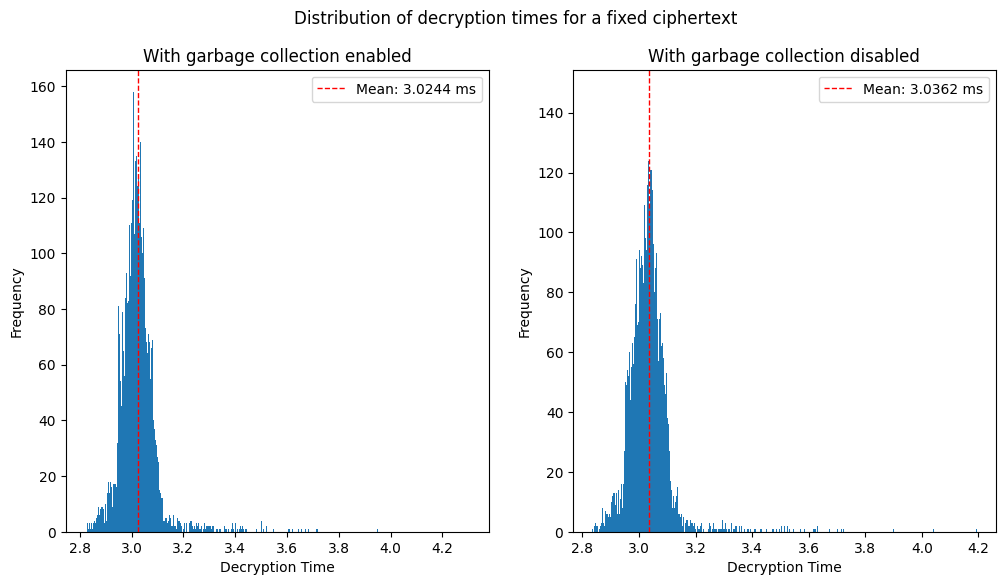

In [61]:
plt.figure(figsize=(12, 6))
plt.suptitle("Distribution of decryption times for a fixed ciphertext")
plt.subplot(1, 2, 1)
plt.hist(samples_stats_gc_enabled, bins=1000)
plt.axvline(np.mean(samples_stats_gc_enabled), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(samples_stats_gc_enabled):.4f} ms')
plt.title("With garbage collection enabled")
plt.xlabel("Decryption Time")
plt.ylabel("Frequency")
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(samples_stats_gc_disabled, bins=1000)
plt.axvline(np.mean(samples_stats_gc_disabled), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(samples_stats_gc_disabled):.4f} ms')
plt.title("With garbage collection disabled")
plt.xlabel("Decryption Time")
plt.ylabel("Frequency")
plt.legend()
plt.show()

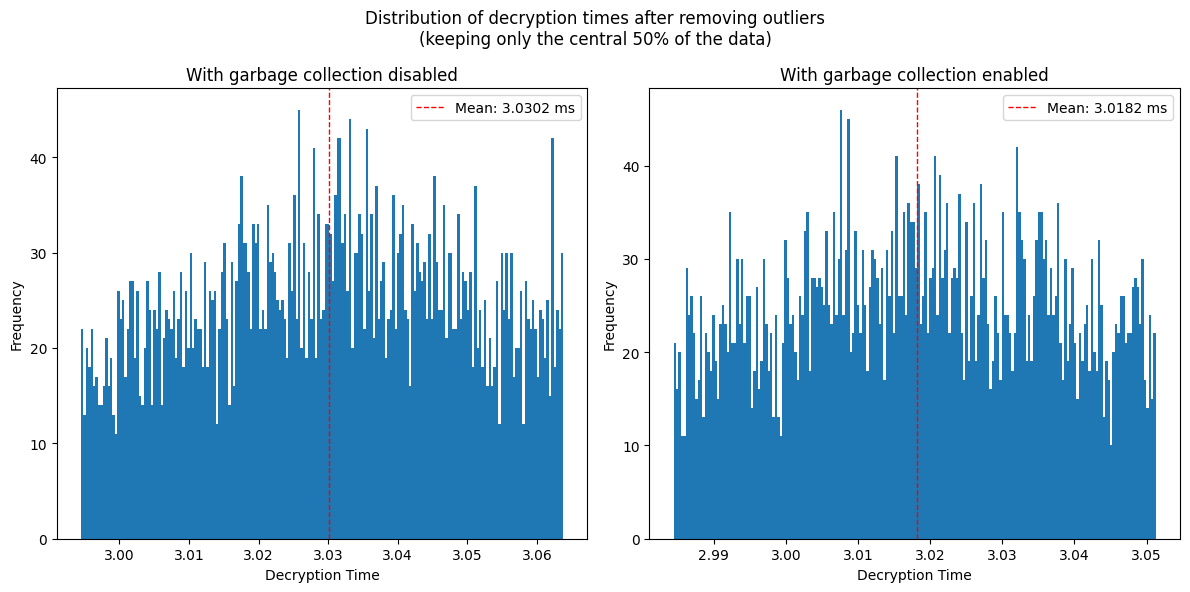

In [62]:
def remove_outliers(samples, percentile=0.25):
    samples = np.asarray(samples)
    
    if percentile >= 1:
        percentile /= 100
    
    down = np.percentile(samples, percentile * 100)
    up = np.percentile(samples, (1 - percentile) * 100)
    
    return samples[(samples >= down) & (samples <= up)]

percentile = 25
samples_stats_gc_enabled_filtered = remove_outliers(samples_stats_gc_enabled, percentile=percentile)
samples_stats_gc_disabled_filtered = remove_outliers(samples_stats_gc_disabled, percentile=percentile)

plt.figure(figsize=(12, 6))
plt.suptitle(f"Distribution of decryption times after removing outliers\n(keeping only the central {100 - 2 * percentile}% of the data)")
plt.subplot(1, 2, 1)
plt.hist(samples_stats_gc_disabled_filtered, bins=200)
plt.axvline(np.mean(samples_stats_gc_disabled_filtered), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(samples_stats_gc_disabled_filtered):.4f} ms')
plt.title("With garbage collection disabled")
plt.xlabel("Decryption Time")
plt.ylabel("Frequency")
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(samples_stats_gc_enabled_filtered, bins=200)
plt.axvline(np.mean(samples_stats_gc_enabled_filtered), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(samples_stats_gc_enabled_filtered):.4f} ms')
plt.title("With garbage collection enabled")
plt.xlabel("Decryption Time")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


In [64]:
def get_samples_stats_prediction_branching(RSA_instance: RSA, d_A: int, num_samples: int = 10000, garbage_enabled: bool = False, delay: float = 0.0, progress_bar: bool = False) -> list:
    """
    Collect decryption times for a fixed ciphertext to analyze the distribution of decryption times.

    Parameters
    ----------
    RSA_instance : RSA
        An instance of the RSA class.
    d_A : int
        The private key to use for decryption.
    num_samples : int
        Number of samples to collect.

    Returns
    -------
    list
        A list of decryption times in nanoseconds.
    """
    if delay == 0.0:
        return get_samples_stats(RSA_instance, d_A, num_samples, garbage_enabled, progress_bar)
    
    gc_was_enabled = gc.isenabled()

    if garbage_enabled:
        gc.enable()
    else:
        gc.disable()
    samples_stats = []
    for _ in tqdm(range(num_samples), disable=not progress_bar):
        time.sleep(delay)
        start_time = time.perf_counter_ns()
        RSA_instance.decrypt(d_A)
        end_time = time.perf_counter_ns()
        samples_stats.append(end_time - start_time)
    
    # Restore garbage collection state
    if gc_was_enabled:
        gc.enable()
    else:
        gc.disable()

    return np.array(samples_stats)

In [66]:
samples_stats_prediction_branching = get_samples_stats_prediction_branching(RSA_instance, d_A, num_samples=10000, garbage_enabled=False, delay=0.001, progress_bar=True) / 1e6

100%|██████████| 10000/10000 [00:43<00:00, 229.50it/s]


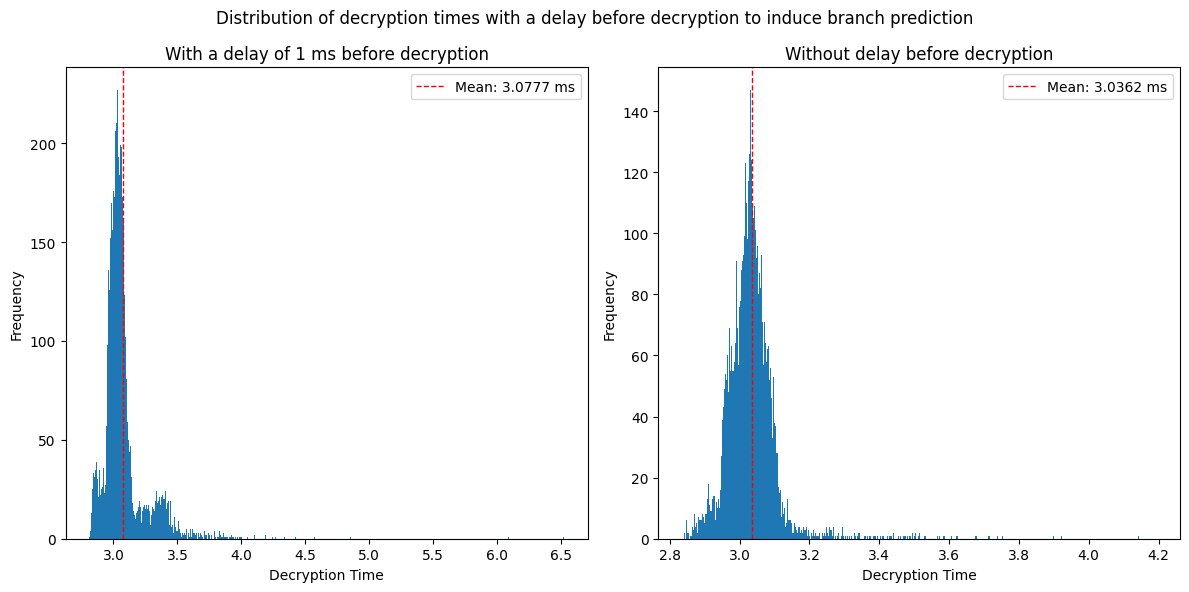

In [67]:
plt.figure(figsize=(12, 6))
plt.suptitle("Distribution of decryption times with a delay before decryption to induce branch prediction")
plt.subplot(1, 2, 1)
plt.hist(samples_stats_prediction_branching, bins=1000)
plt.axvline(np.mean(samples_stats_prediction_branching), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(samples_stats_prediction_branching):.4f} ms')
plt.title("With a delay of 1 ms before decryption")
plt.xlabel("Decryption Time")
plt.ylabel("Frequency")
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(samples_stats_gc_disabled, bins=1000)
plt.axvline(np.mean(samples_stats_gc_disabled), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(samples_stats_gc_disabled):.4f} ms')
plt.title("Without delay before decryption")
plt.xlabel("Decryption Time")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

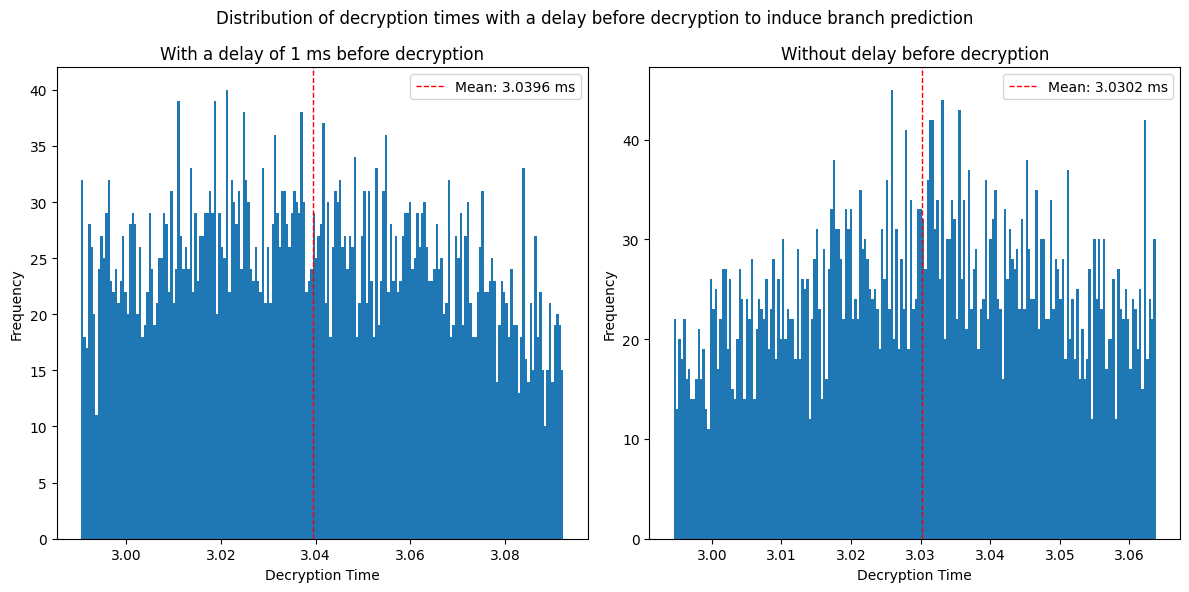

In [69]:
plt.figure(figsize=(12, 6))
plt.suptitle("Distribution of decryption times with a delay before decryption to induce branch prediction")
plt.subplot(1, 2, 1)
plt.hist(remove_outliers(samples_stats_prediction_branching, percentile=percentile), bins=200)
plt.axvline(np.mean(remove_outliers(samples_stats_prediction_branching, percentile=percentile)), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(remove_outliers(samples_stats_prediction_branching, percentile=percentile)):.4f} ms')
plt.title("With a delay of 1 ms before decryption")
plt.xlabel("Decryption Time")
plt.ylabel("Frequency")
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(remove_outliers(samples_stats_gc_disabled, percentile=percentile), bins=200)
plt.axvline(np.mean(remove_outliers(samples_stats_gc_disabled, percentile=percentile)), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(remove_outliers(samples_stats_gc_disabled, percentile=percentile)):.4f} ms')
plt.title("Without delay before decryption")
plt.xlabel("Decryption Time")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

In [96]:
small_key = d_A & ((1 << 16) - 1)
h0_small_key = small_key
h1_small_key = small_key | (1 << 16)

In [97]:
samples_stats_h0_branching = get_samples_stats_prediction_branching(RSA_instance, h0_small_key, num_samples=10000, garbage_enabled=False, delay=0.0, progress_bar=True) / 1e6
samples_stats_h1_branching = get_samples_stats_prediction_branching(RSA_instance, h1_small_key, num_samples=10000, garbage_enabled=False, delay=0.0, progress_bar=True) / 1e6

100%|██████████| 10000/10000 [00:30<00:00, 331.85it/s]


In [98]:
samples_stats_h0_garbage = get_samples_stats_prediction_branching(RSA_instance, h0_small_key, num_samples=10000, garbage_enabled=True, delay=0.0001, progress_bar=True) / 1e6
samples_stats_h1_garbage = get_samples_stats_prediction_branching(RSA_instance, h1_small_key, num_samples=10000, garbage_enabled=True, delay=0.0001, progress_bar=True) / 1e6

100%|██████████| 10000/10000 [00:35<00:00, 282.42it/s]


In [99]:
samples_stats_h0 = get_samples_stats_prediction_branching(RSA_instance, h0_small_key, num_samples=10000, garbage_enabled=False, delay=0.0001, progress_bar=True) / 1e6
samples_stats_h1 = get_samples_stats_prediction_branching(RSA_instance, h1_small_key, num_samples=10000, garbage_enabled=False, delay=0.0001, progress_bar=True) / 1e6

100%|██████████| 10000/10000 [00:35<00:00, 281.83it/s]


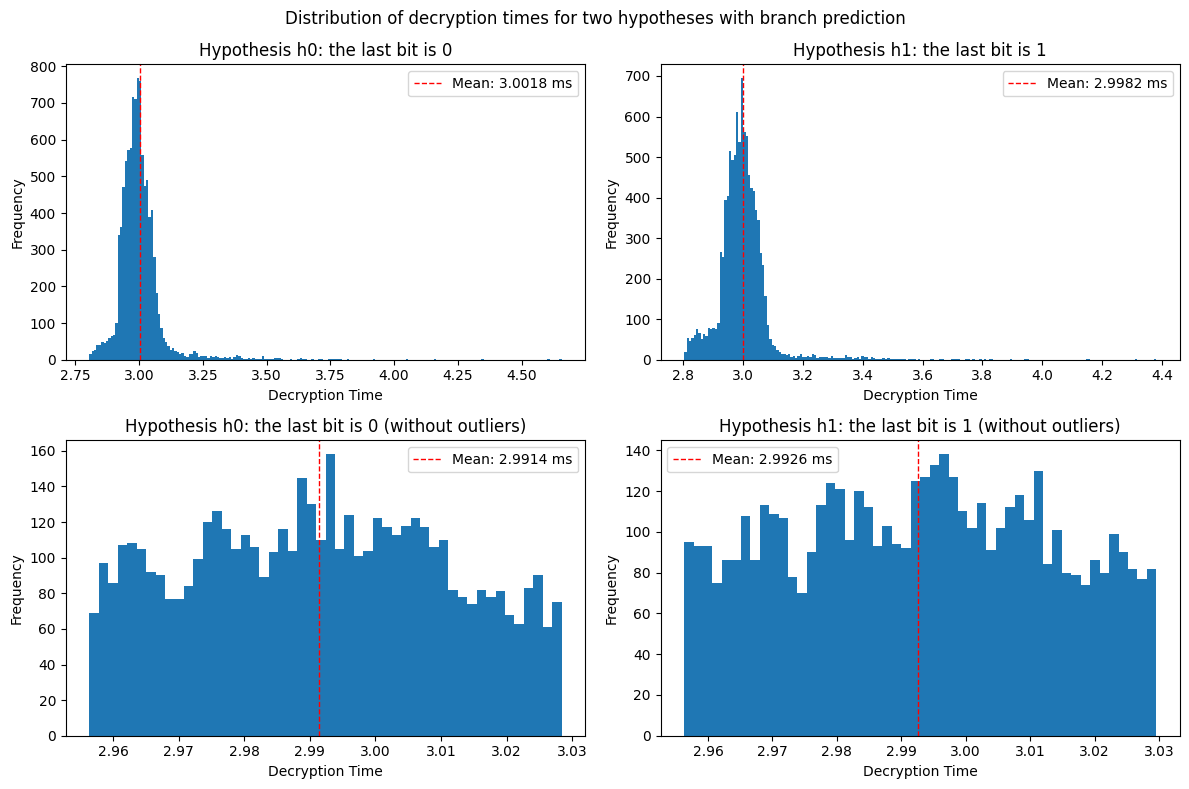

In [100]:
plt.figure(figsize=(12, 8))
plt.suptitle("Distribution of decryption times for two hypotheses with branch prediction")
plt.subplot(2, 2, 1)
plt.hist(samples_stats_h0_branching, bins=200)
plt.axvline(np.mean(samples_stats_h0_branching), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(samples_stats_h0_branching):.4f} ms')
plt.title("Hypothesis h0: the last bit is 0")
plt.xlabel("Decryption Time")
plt.ylabel("Frequency")
plt.legend()
plt.subplot(2, 2, 2)
plt.hist(samples_stats_h1_branching, bins=200)
plt.axvline(np.mean(samples_stats_h1_branching), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(samples_stats_h1_branching):.4f} ms')
plt.title("Hypothesis h1: the last bit is 1")
plt.xlabel("Decryption Time")
plt.ylabel("Frequency")
plt.legend()
plt.subplot(2, 2, 3)
plt.hist(remove_outliers(samples_stats_h0_branching, percentile=percentile), bins=50)
plt.axvline(np.mean(remove_outliers(samples_stats_h0_branching, percentile=percentile)), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(remove_outliers(samples_stats_h0_branching, percentile=percentile)):.4f} ms')
plt.title("Hypothesis h0: the last bit is 0 (without outliers)")
plt.xlabel("Decryption Time")
plt.ylabel("Frequency")
plt.legend()
plt.subplot(2, 2, 4)
plt.hist(remove_outliers(samples_stats_h1_branching, percentile=percentile), bins=50)
plt.axvline(np.mean(remove_outliers(samples_stats_h1_branching, percentile=percentile)), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(remove_outliers(samples_stats_h1_branching, percentile=percentile)):.4f} ms')
plt.title("Hypothesis h1: the last bit is 1 (without outliers)")
plt.xlabel("Decryption Time")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

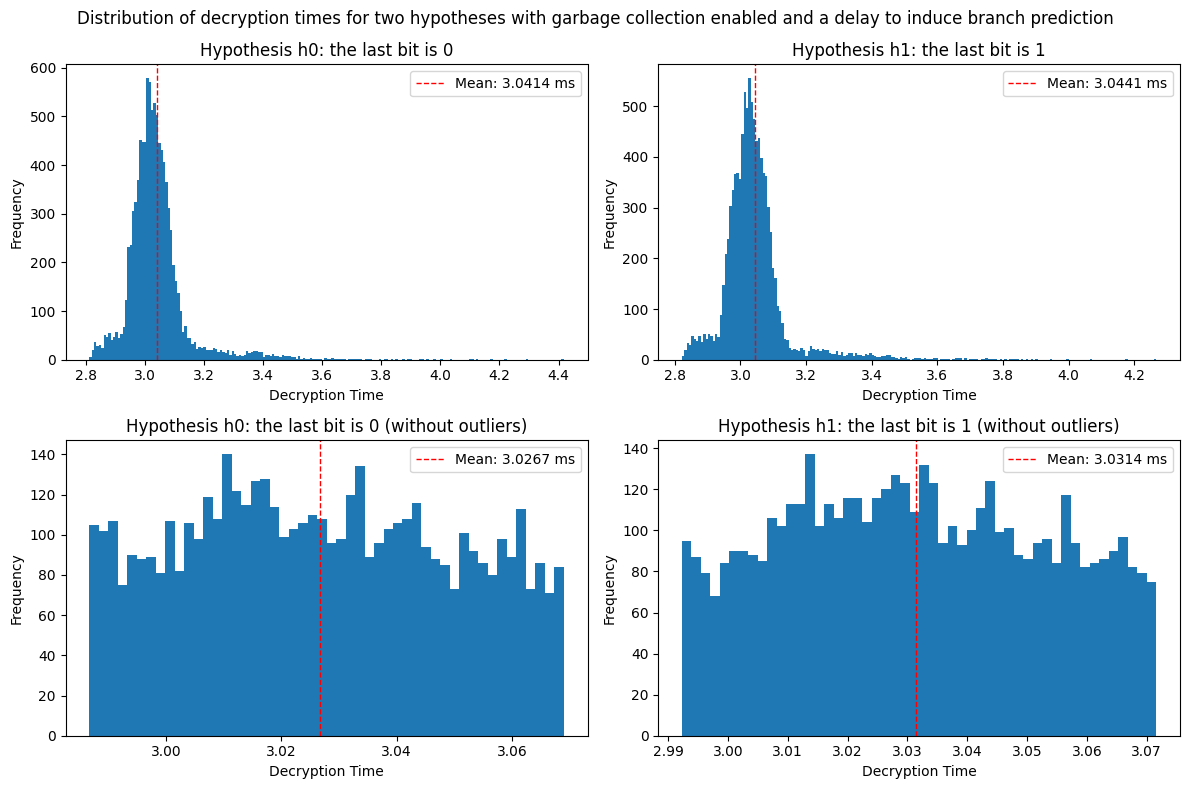

In [101]:
plt.figure(figsize=(12, 8))
plt.suptitle("Distribution of decryption times for two hypotheses with garbage collection enabled and a delay to induce branch prediction")
plt.subplot(2, 2, 1)
plt.hist(samples_stats_h0_garbage, bins=200)
plt.axvline(np.mean(samples_stats_h0_garbage), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(samples_stats_h0_garbage):.4f} ms')
plt.title("Hypothesis h0: the last bit is 0")
plt.xlabel("Decryption Time")
plt.ylabel("Frequency")
plt.legend()
plt.subplot(2, 2, 2)
plt.hist(samples_stats_h1_garbage, bins=200)
plt.axvline(np.mean(samples_stats_h1_garbage), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(samples_stats_h1_garbage):.4f} ms')
plt.title("Hypothesis h1: the last bit is 1")
plt.xlabel("Decryption Time")
plt.ylabel("Frequency")
plt.legend()
plt.subplot(2, 2, 3)
plt.hist(remove_outliers(samples_stats_h0_garbage, percentile=percentile), bins=50)
plt.axvline(np.mean(remove_outliers(samples_stats_h0_garbage, percentile=percentile)), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(remove_outliers(samples_stats_h0_garbage, percentile=percentile)):.4f} ms')
plt.title("Hypothesis h0: the last bit is 0 (without outliers)")
plt.xlabel("Decryption Time")
plt.ylabel("Frequency")
plt.legend()
plt.subplot(2, 2, 4)
plt.hist(remove_outliers(samples_stats_h1_garbage, percentile=percentile), bins=50)
plt.axvline(np.mean(remove_outliers(samples_stats_h1_garbage, percentile=percentile)), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(remove_outliers(samples_stats_h1_garbage, percentile=percentile)):.4f} ms')
plt.title("Hypothesis h1: the last bit is 1 (without outliers)")
plt.xlabel("Decryption Time")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

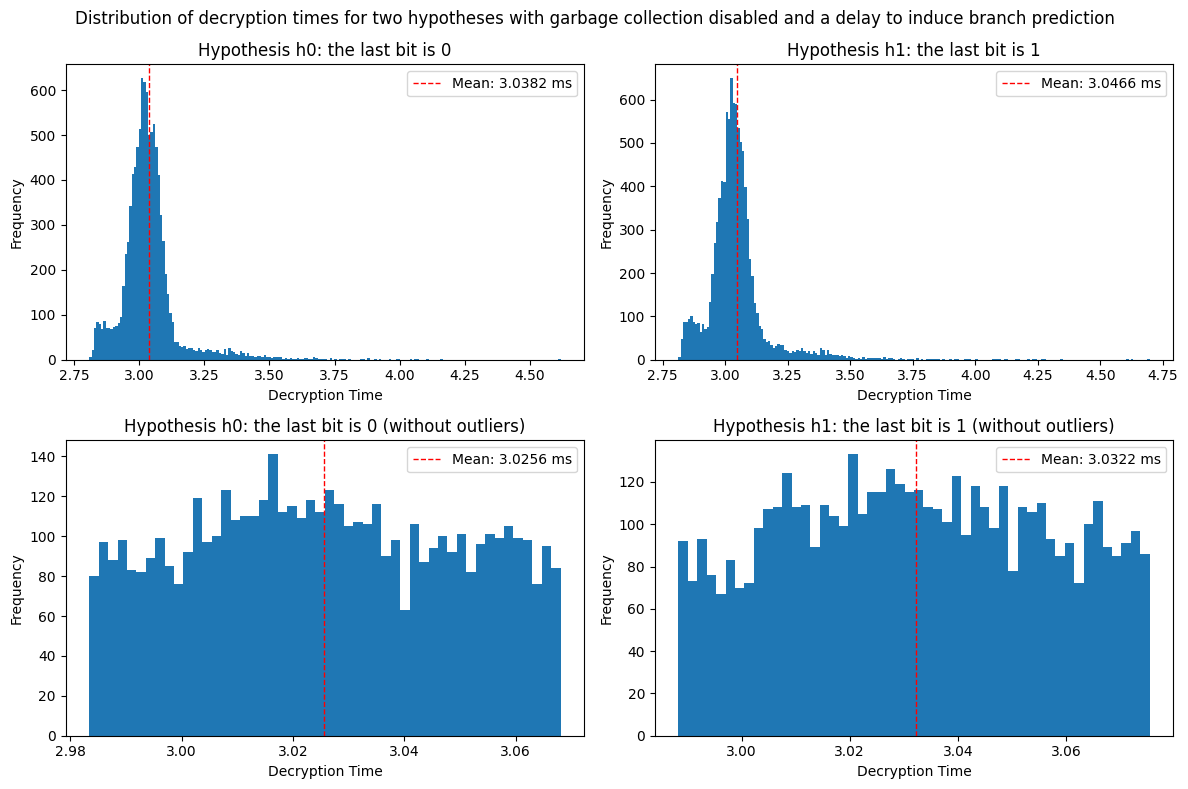

In [102]:
plt.figure(figsize=(12, 8))
plt.suptitle("Distribution of decryption times for two hypotheses with garbage collection disabled and a delay to induce branch prediction")
plt.subplot(2, 2, 1)
plt.hist(samples_stats_h0, bins=200)
plt.axvline(np.mean(samples_stats_h0), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(samples_stats_h0):.4f} ms')
plt.title("Hypothesis h0: the last bit is 0")
plt.xlabel("Decryption Time")
plt.ylabel("Frequency")
plt.legend()
plt.subplot(2, 2, 2)
plt.hist(samples_stats_h1, bins=200)
plt.axvline(np.mean(samples_stats_h1), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(samples_stats_h1):.4f} ms')
plt.title("Hypothesis h1: the last bit is 1")
plt.xlabel("Decryption Time")
plt.ylabel("Frequency")
plt.legend()
plt.subplot(2, 2, 3)
plt.hist(remove_outliers(samples_stats_h0, percentile=percentile), bins=50)
plt.axvline(np.mean(remove_outliers(samples_stats_h0, percentile=percentile)), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(remove_outliers(samples_stats_h0, percentile=percentile)):.4f} ms')
plt.title("Hypothesis h0: the last bit is 0 (without outliers)")
plt.xlabel("Decryption Time")
plt.ylabel("Frequency")
plt.legend()
plt.subplot(2, 2, 4)
plt.hist(remove_outliers(samples_stats_h1, percentile=percentile), bins=50)
plt.axvline(np.mean(remove_outliers(samples_stats_h1, percentile=percentile)), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(remove_outliers(samples_stats_h1, percentile=percentile)):.4f} ms')
plt.title("Hypothesis h1: the last bit is 1 (without outliers)")
plt.xlabel("Decryption Time")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

In [103]:
def collect_samples(RSA_instance: RSA, num_samples: int = 1000, num_repetitions: int = 1, server: bool = True, private_key: int = None, delay: float = 0.0001, garbage_enabled: bool = False, progress_bar: bool = True) -> list:
    """
    Collect samples of decryption times for different cipher texts.

    Parameters
    ----------
    RSA_instance : RSA
        An instance of the RSA class.
    num_samples : int
        Number of samples to collect.
    num_repetitions : int
        Number of times to repeat each measurement.
    server : bool
        Whether to simulate the server side.
    private_key : int
        The private key to test (only used when server=False).
    delay : float
        A delay in seconds to introduce before decryption to induce branch prediction effects.
    garbage_enabled : bool
        Whether to enable garbage collection during sample collection (can slow down the process but reduce memory usage).
    progress_bar : bool
        Whether to display a progress bar during sample collection.

    Returns
    -------
    list
        A list of tuples containing (tested_cipher, decryption_time).
    """
    samples = []

    # Backup the state of garbage collection to restore it later
    gc_was_enabled = gc.isenabled()

    # Set garbage collection state according to the parameter
    if garbage_enabled:
        gc.enable()
    else:
        gc.disable()

    try:
        for _ in tqdm(range(num_samples), desc="Collecting server samples" if server else "Collecting samples", disable=not progress_bar):
            tested_cipher = random.randint(1, RSA_instance.n - 1)
            decryption_times = []

            # delay to induce branch prediction effects
            if delay > 0:
                time.sleep(delay)

            if server:
                for _ in range(num_repetitions):
                    start_time = time.perf_counter_ns()
                    RSA_instance.decrypt(tested_cipher)
                    end_time = time.perf_counter_ns()
                    decryption_times.append(end_time - start_time)

                decryption_time = np.mean(decryption_times)

            else:
                assert private_key is not None, "Private key must be provided when server=False"

                start_time = time.perf_counter_ns()
                for _ in range(num_repetitions):
                    RSA_instance.decrypt(tested_cipher, private_key=private_key)
                end_time = time.perf_counter_ns()

                decryption_time = (end_time - start_time) / num_repetitions

            samples.append([tested_cipher, decryption_time])

    finally:
        # Restore the original state of garbage collection
        if gc_was_enabled:
            gc.enable()
        else:
            gc.disable()

    return np.array(samples)

In [ ]:
timing_attack(RSA_instance, num_samples=1000, num_repetitions=1000, num_iterations=4, num_known_bits=16, buffer_size=4, garbage_enabled=True, progress_bar=True)